# Linear regression from Scratch

# Problem definition
- What are inputs and outputs?

*Linear regression* is a statistical technique used to find the relationship between variables. It's the most fundemental model in machine learning

# Mathematical formulation

## 1. Linear regression equation

### Math definition

$$y = mx + b$$

where
-  $y$ - dependent variable
-  $x$ - independent variable
-  $m$ - **slope** of the line(how much $y$ changes when $x$ increases by 1)
-  $b$ - **y-intercept** (value of $y$ when $x=0$)

### Definition for machine learning
In ML the same equation for a linear regression will be

$$y' = b + w_1x_1$$

where
- $y'$ - predicted **output**
- $x_1$ - **input** feature
- $b$ - **bias(intercept)** of the model. It allows the model to fit data not centered at zero
- $w_1$ - **weight(slope)** of the feature. How strongly each feature affects the output

## 2. Cost function

**Cost Function** guides the model during **training** (optimization objective). The overall measure of model performance used to update parameters. We usually don’t directly “use” the value of $J$ to update the parameters

### Mean Squared Error (MSE)
$$J(w, b) = \frac{1}{n} \sum_{i=1}^{n} (\hat{y}_i - y_i)^2$$

where
* $y_i$ - actual value
* $\hat{y}_i$ - predicted value
* $n$ - number of data points

Often written with $\frac{1}{2n}$ for easier differentiation
$$J(w, b) = \frac{1}{2n} \sum_{i=1}^{n} (\hat{y}_i - y_i)^2$$

Instead of just error, we use squared error:
- removes sign (positive/negative canceling)
- makes the function smooth & differentiable
- penalizes large errors more

## 3. Gradient Descent
**Gradient descent** is a mathematical technique that **iteratively** finds the **weights** and **bias** that produce the model with the lowest loss

### Partial Derivatives

For weight $w$:
$$\frac{\partial J}{\partial w} = \frac{1}{n} \sum_{i=1}^{n} (\hat{y}_i - y_i)x_i$$

For bias $b$:
$$\frac{\partial J}{\partial b} = \frac{1}{n} \sum_{i=1}^{n} (\hat{y}_i - y_i)$$

### Update Rules

$$w = w - \alpha \cdot \frac{\partial J}{\partial w}$$

$$b = b - \alpha \cdot \frac{\partial J}{\partial b}$$

- $\alpha$ - **learning rate**
    - controls how much the model parameters change in response to the error each time the model is updated

## 4. Regularization
**Regularization prevents** **overfitting** by penalizing large weights

### L1 Regularization (Lasso)
Adds absolute weights penalty:

$$J(w, b) = \frac{1}{2n} \sum (\hat{y} - y)^2 + \lambda \sum |w|$$

* Can shrink weights to zero
* Performs feature selection

### L2 Regularization (Ridge)
Adds squared weights penalty:

$$J(w, b) = \frac{1}{2n} \sum (\hat{y} - y)^2 + \lambda \sum w^2$$

* Shrinks weights
* Keeps all features


### Effect on Gradient Descent

**L2 weight update:**
$$w = w - \alpha \left(\frac{\partial J}{\partial w} + 2\lambda w\right)$$

# Implementation
> Import of implementation
> class with consistent API from py file

In [1]:
# Imports
import pandas as pd
from sklearn.datasets import load_diabetes, make_regression
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [2]:
import sys
import os

sys.path.append(os.path.abspath(".."))

# Create folders for saved outputs
os.makedirs("outputs/linear", exist_ok=True)
os.makedirs("outputs/plots/linear", exist_ok=True)
os.makedirs("outputs/tables/linear", exist_ok=True)

In [ ]:
# Custom 
from ml_from_scratch.linear_models.linear_regression import SimpleLinearRegression
# from ml_from_scratch.util import train_test_split
from ml_from_scratch.report_utils import regression_report, print_report, save_predictions, save_metrics, save_predictions, plot_predictions

# Real dataset example

Test model implementation on the Diabetes dataset from `sklearn`. This is a real regression task where the target is a quantitative disease progression measure

In [ ]:
# 1 - Load dataset
data = load_diabetes()

X = data.data
y = data.target

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

df = pd.DataFrame(X, columns=data.feature_names)
df["target"] = y
df.head()

# 2 - Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Feature shape: (442, 10)
Target shape: (442,)
Train shape: (353, 10)
Test shape: (89, 10)


In [5]:
# 3 - Train from-scratch model
scratch_model = SimpleLinearRegression(
    learning_rate=0.01,
    epochs=1000,
    penalty=None,
    alpha=0.0
)

scratch_model.fit(X_train, y_train)
y_pred_scratch = scratch_model.predict(X_test)

scratch_metrics = regression_report(y_test, y_pred_scratch)
print_report("From-scratch model on real dataset", scratch_metrics)

From-scratch model on real dataset
MAE: 61.8725
MSE: 5010.3536
RMSE: 70.7839
R2: 0.0543
----------------------------------------


In [6]:
# 4 - Train sklearn baseline
sklearn_model = LinearRegression()
sklearn_model.fit(X_train, y_train)
y_pred_sklearn = sklearn_model.predict(X_test)

sklearn_metrics = regression_report(y_test, y_pred_sklearn)
print_report("Sklearn model on real dataset", sklearn_metrics)

Sklearn model on real dataset
MAE: 42.7941
MSE: 2900.1936
RMSE: 53.8534
R2: 0.4526
----------------------------------------


In [7]:
# 5 - Compare results
comparison_real = pd.DataFrame({
    "Metric": ["MAE", "MSE", "RMSE", "R2"],
    "Scratch": [
        scratch_metrics["MAE"],
        scratch_metrics["MSE"],
        scratch_metrics["RMSE"],
        scratch_metrics["R2"]
    ],
    "Sklearn": [
        sklearn_metrics["MAE"],
        sklearn_metrics["MSE"],
        sklearn_metrics["RMSE"],
        sklearn_metrics["R2"]
    ]
})

comparison_real

,Metric,Scratch,Sklearn
0,MAE,61.872517,42.794095
1,MSE,5010.353588,2900.193628
2,RMSE,70.783851,53.853446
3,R2,0.054320,0.452603


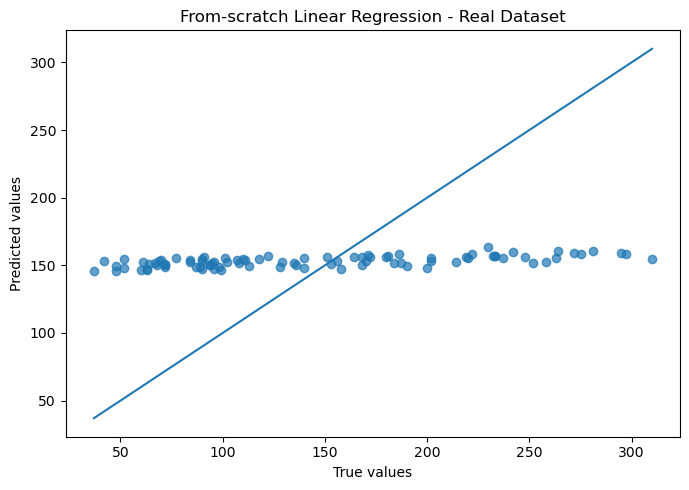

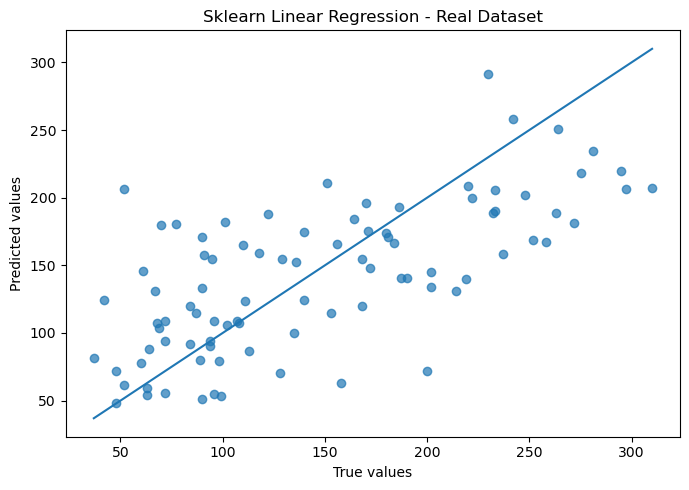

In [ ]:
# 6 - Save predictions and plot
real_predictions = pd.DataFrame({
    "y_true": y_test,
    "y_pred_scratch": y_pred_scratch,
    "y_pred_sklearn": y_pred_sklearn
})

real_predictions.to_csv("outputs/tables/linear/linear_real_dataset_predictions.csv", index=False)
comparison_real.to_csv("outputs/tables/linear/linear_real_dataset_comparison.csv", index=False)

plot_predictions(
    y_test,
    y_pred_scratch,
    "From-scratch Linear Regression - Real Dataset",
    "outputs/plots/linear/linear_real_dataset_tuned_scratch.png"
)

plot_predictions(
    y_test,
    y_pred_sklearn,
    "Sklearn Linear Regression - Real Dataset",
    "outputs/plots/linear/linear_real_dataset_sklearn.png"
)

## Change params for from-skcratch model

In [9]:
# Train from-scratch model with new params
scratch_model_tuned = SimpleLinearRegression(
    learning_rate=0.01,
    epochs=50000,
    penalty=None,
    alpha=0.0
)

scratch_model_tuned.fit(X_train, y_train)
y_pred_scratch = scratch_model_tuned.predict(X_test)

tuned_scratch_metrics = regression_report(y_test, y_pred_scratch)
print_report("From-scratch tuned model on real dataset", tuned_scratch_metrics)

From-scratch tuned model on real dataset
MAE: 43.3210
MSE: 2882.1214
RMSE: 53.6854
R2: 0.4560
----------------------------------------


In [10]:
# Add results to the comparison table
comparison_real["Tuned Scratch"] = comparison_real["Metric"].map({
    "MAE": tuned_scratch_metrics["MAE"],
    "MSE": tuned_scratch_metrics["MSE"],
    "RMSE": tuned_scratch_metrics["RMSE"],
    "R2": tuned_scratch_metrics["R2"]
})

comparison_real

,Metric,Scratch,Sklearn,Tuned Scratch
0,MAE,61.872517,42.794095,43.320984
1,MSE,5010.353588,2900.193628,2882.121421
2,RMSE,70.783851,53.853446,53.685393
3,R2,0.054320,0.452603,0.456014


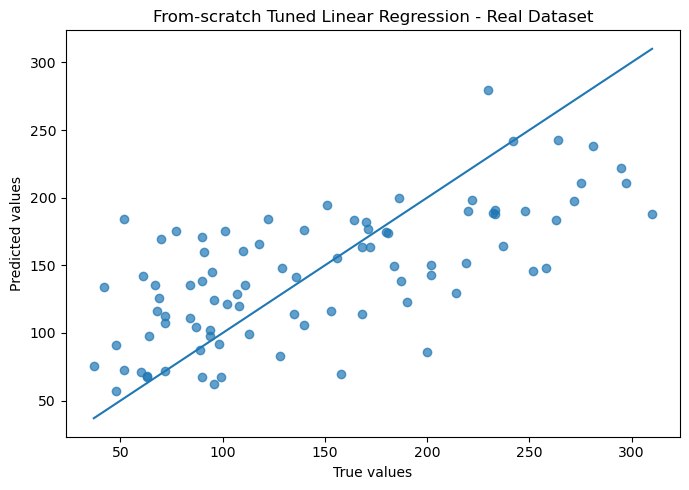

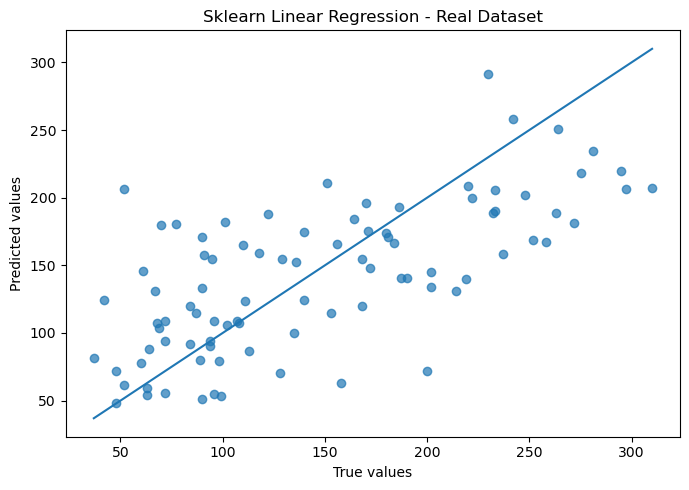

In [11]:
# Save predictions and plot
real_predictions = pd.DataFrame({
    "y_true": y_test,
    "y_pred_scratch": y_pred_scratch,
    "y_pred_sklearn": y_pred_sklearn
})

real_predictions.to_csv("outputs/tables/linear/linear_real_dataset_predictions.csv", index=False)
comparison_real.to_csv("outputs/tables/linear/linear_real_dataset_comparison.csv", index=False)

plot_predictions(
    y_test,
    y_pred_scratch,
    "From-scratch Tuned Linear Regression - Real Dataset",
    "outputs/plots/linear/linear_real_dataset_scratch.png"
)

plot_predictions(
    y_test,
    y_pred_sklearn,
    "Sklearn Linear Regression - Real Dataset",
    "outputs/plots/linear/linear_real_dataset_sklearn.png"
)

# Small synthetic example

Test using artificial linear data. This is useful because it is possible to control the data generation process and can quickly test whether the model behaves as expected

In [12]:
# 1 - Generate synthetic data
X_syn, y_syn = make_regression(
    n_samples=300,
    n_features=3,
    noise=15,
    random_state=42
)

X_syn_train, X_syn_test, y_syn_train, y_syn_test = train_test_split(
    X_syn, y_syn, test_size=0.2, random_state=42
)

print("Synthetic train shape:", X_syn_train.shape)
print("Synthetic test shape:", X_syn_test.shape)

Synthetic train shape: (240, 3)
Synthetic test shape: (60, 3)


In [13]:
# 2 - Train from-scratch model on synthetic data
scratch_syn_model = SimpleLinearRegression(
    learning_rate=0.01,
    epochs=5000
)

scratch_syn_model.fit(X_syn_train, y_syn_train)
y_syn_pred_scratch = scratch_syn_model.predict(X_syn_test)

scratch_syn_metrics = regression_report(y_syn_test, y_syn_pred_scratch)
print_report("From-scratch model on synthetic dataset", scratch_syn_metrics)

From-scratch model on synthetic dataset
MAE: 10.5240
MSE: 170.8143
RMSE: 13.0696
R2: 0.9897
----------------------------------------


In [14]:
# 3 - Train sklearn baseline on synthetic data
sklearn_syn_model = LinearRegression()
sklearn_syn_model.fit(X_syn_train, y_syn_train)
y_syn_pred_sklearn = sklearn_syn_model.predict(X_syn_test)

sklearn_syn_metrics = regression_report(y_syn_test, y_syn_pred_sklearn)
print_report("Sklearn model on synthetic dataset", sklearn_syn_metrics)

Sklearn model on synthetic dataset
MAE: 10.5240
MSE: 170.8143
RMSE: 13.0696
R2: 0.9897
----------------------------------------


In [15]:
# 4 - Compare results
comparison_syn = pd.DataFrame({
    "Metric": ["MAE", "MSE", "RMSE", "R2"],
    "Scratch": [
        scratch_syn_metrics["MAE"],
        scratch_syn_metrics["MSE"],
        scratch_syn_metrics["RMSE"],
        scratch_syn_metrics["R2"]
    ],
    "Sklearn": [
        sklearn_syn_metrics["MAE"],
        sklearn_syn_metrics["MSE"],
        sklearn_syn_metrics["RMSE"],
        sklearn_syn_metrics["R2"]
    ]
})

comparison_syn

,Metric,Scratch,Sklearn
0,MAE,10.523971,10.523971
1,MSE,170.814334,170.814334
2,RMSE,13.069596,13.069596
3,R2,0.989684,0.989684


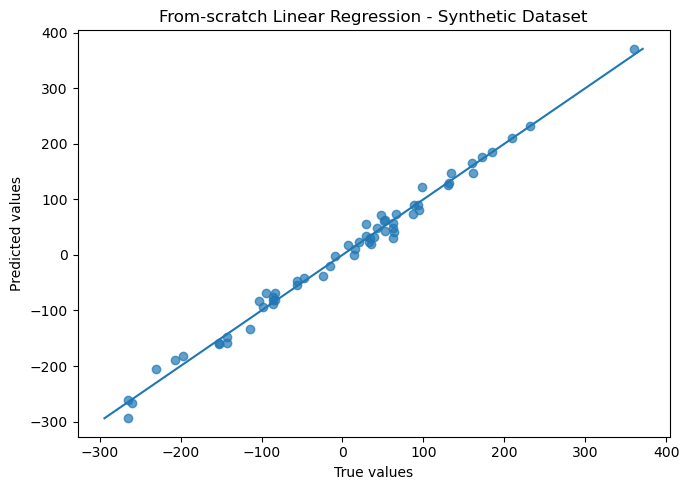

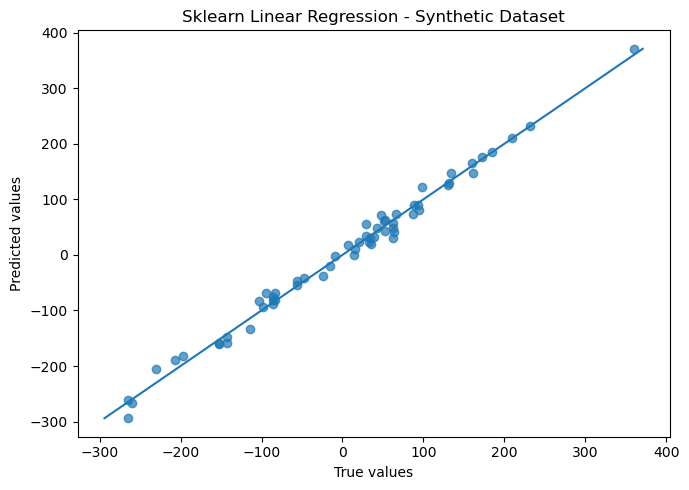

In [16]:
# 5 - Save synthetic results
synthetic_predictions = pd.DataFrame({
    "y_true": y_syn_test,
    "y_pred_scratch": y_syn_pred_scratch,
    "y_pred_sklearn": y_syn_pred_sklearn
})

synthetic_predictions.to_csv("outputs/tables/linear/synthetic_dataset_predictions.csv", index=False)
comparison_syn.to_csv("outputs/tables/linear/synthetic_dataset_comparison.csv", index=False)

plot_predictions(
    y_syn_test,
    y_syn_pred_scratch,
    "From-scratch Linear Regression - Synthetic Dataset",
    "outputs/plots/linear/synthetic_dataset_scratch.png"
)

plot_predictions(
    y_syn_test,
    y_syn_pred_sklearn,
    "Sklearn Linear Regression - Synthetic Dataset",
    "outputs/plots/linear/synthetic_dataset_sklearn.png"
)

# Save all results summary

In [17]:
linear_resuls = {
    "real_dataset": {
        "scratch": scratch_metrics,
        "tuned_scratch": tuned_scratch_metrics,
        "sklearn": sklearn_metrics
    },
    "synthetic_dataset": {
        "scratch": scratch_syn_metrics,
        "sklearn": sklearn_syn_metrics
    }
}

save_metrics("outputs/linear/linear_resuls.json", linear_resuls)

print("All results saved to /outputs/linear")

All results saved to /outputs/linear


In [18]:
print("Scratch model parameters on real dataset:")
print(scratch_model.get_params())

print("\nScratch model parameters on synthetic dataset:")
print(scratch_syn_model.get_params())

Scratch model parameters on real dataset:
{'weights': array([  6.95021174,   0.05931667,  21.84187963,  16.40104773,
         6.80499335,   5.11280526, -13.67762448,  15.11946625,
        19.99332247,  14.34145581]), 'bias': 153.61230573046473, 'learning_rate': 0.01, 'epochs': 1000, 'penalty': None}

Scratch model parameters on synthetic dataset:
{'weights': array([83.00713972, 81.48591866, 16.3731598 ]), 'bias': 0.5410881865363631, 'learning_rate': 0.01, 'epochs': 5000, 'penalty': None}


# Conclusion

- the from-scratch model works correctly and produces reasonable predictions
- on both datasets, metric values show whether the custom implementation is close to the library version

## Why does the from-scratch model perform worse on the real dataset?
On the real dataset, the from-scratch implementation performs significantly worse than the sklearn model:
- $R^2$ score is much lower (~0.054 vs ~0.45)
- The model struggles to capture the full variation of target values

This indicates **underfitting** in the custom implementation. To improve convergence, the model was tuned by increase epochs:
- The model converges more effectively
- Predictions better align with true values

The main issue is that the custom implementation uses **gradient descent**, which is sensitive to feature scaling. In contrast, sklearn's `LinearRegression` uses a **closed-form solution (normal equation)**, which:
- does not rely on iterative optimization
- is not affected by feature scaling in the same way

## Result
- **Closed-form solutions (sklearn)** are robust and fast
- **Gradient descent implementations** require careful tuning:
  - feature scaling
  - learning rate
  - number of epochs